#   <b><font color="navy" size="6">GISMA Cover Page
</font></b>
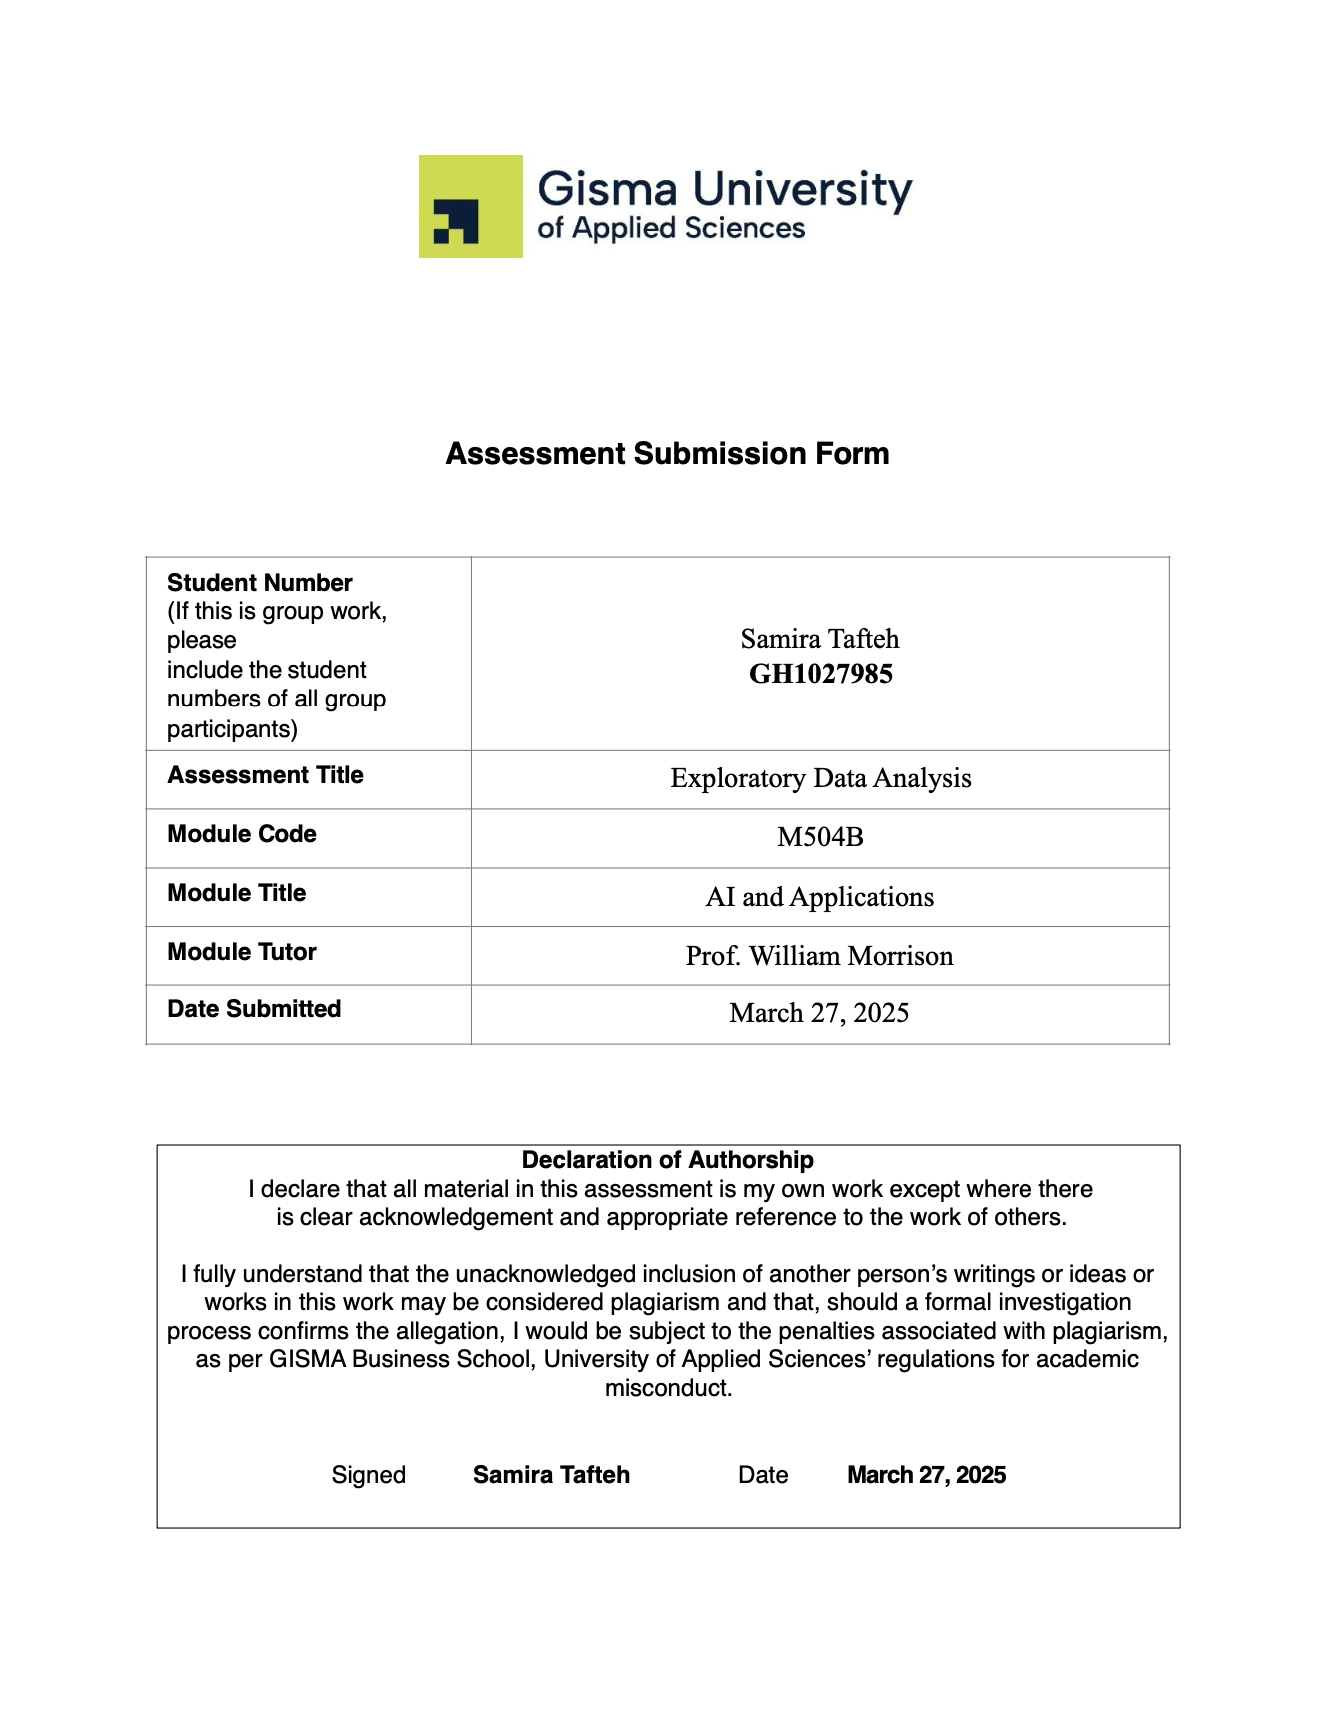

<div align="center">
  <b><font color="navy" size="8">Exploratory Data Analysis of U.S. Accidents for
  an Insurance Company</font></b>
</div>

#   <b><font color="navy" size="6">Business Context
</font></b>

## **Client Company**
Our client is an insurance company. They want to know where/when accidents happen, how serious they are and know thier cuases so they can manage risks in better way. This EDA helps them to decide how much to charge for insurance with fair prices, have enough money ready for faster claims and even make safety programs.


## **Data Available**
In this project I use [U.S. Accidents Dataset](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents), which is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. <b><font color="darkred">(for this part I have copied the description of dataset on Kaggle)
</font></b>

## **Why do they need data scientist? (business objectives)**
As I said before, companies need data scientist for:
- **Risk management:** They can see when/where/why more accidents happen, so they understand risks and try to manage them in best way.
- **Setting fair prices:** They can use data and info to set fair prices.
- **Claims managemnt:** They can use data and info to be ready and have enough fund to help people quickly.
- **Safety programs:** They can help to make roads more safe and even have campaigns to show what they have from data.

#   <b><font color="navy" size="6">Data Exploration
</font></b>

# **Data Integrity Check**

**Name:** US Accidents (2016 - 2023)

**Size:** 7728394 rows * 46 columns

**Questions to ask before analysis**
- Are the column data types correct?
- Is there any missing data? In which coloumns?
- How many unique values per feature? Are any columns redundant?
- Do any of the coloumns contain outliers? How should we deal with them?

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import plotly.express as px
import seaborn as sns

In [40]:
# download the dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")
print("Path to dataset files:", path)
path = os.path.join(path, "US_Accidents_March23.csv")
print("Path to dataset csv:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13
Path to dataset csv: /root/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13/US_Accidents_March23.csv


In [41]:
# load the CSV file
df = pd.read_csv(path)
pd.set_option('display.max_columns', None)
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.87,-84.06,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.90,NaN,91.00,29.68,10.00,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.93,-82.83,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.90,NaN,100.00,29.65,10.00,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.06,-84.03,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.00,33.30,100.00,29.67,10.00,SW,3.50,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.75,-84.21,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.10,31.00,96.00,29.64,9.00,SW,4.60,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.63,-84.19,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.00,33.30,89.00,29.65,6.00,SW,3.50,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [42]:
# column data type
df.dtypes

,0
ID,object
Source,object
Severity,int64
Start_Time,object
End_Time,object
Start_Lat,float64
Start_Lng,float64
End_Lat,float64
End_Lng,float64
Distance(mi),float64


In [43]:
# unique values in each column
for i in df.columns:
  print(i, ':', len(df[i].unique()))

ID : 7728394
Source : 3
Severity : 4
Start_Time : 6131796
End_Time : 6705355
Start_Lat : 2428358
Start_Lng : 2482533
End_Lat : 1568173
End_Lng : 1605790
Distance(mi) : 22382
Description : 3761579
Street : 336307
City : 13679
County : 1871
State : 49
Zipcode : 825095
Country : 1
Timezone : 5
Airport_Code : 2046
Weather_Timestamp : 941332
Temperature(F) : 861
Wind_Chill(F) : 1002
Humidity(%) : 101
Pressure(in) : 1145
Visibility(mi) : 93
Wind_Direction : 25
Wind_Speed(mph) : 185
Precipitation(in) : 300
Weather_Condition : 145
Amenity : 2
Bump : 2
Crossing : 2
Give_Way : 2
Junction : 2
No_Exit : 2
Railway : 2
Roundabout : 2
Station : 2
Stop : 2
Traffic_Calming : 2
Traffic_Signal : 2
Turning_Loop : 1
Sunrise_Sunset : 3
Civil_Twilight : 3
Nautical_Twilight : 3
Astronomical_Twilight : 3


In [44]:
# summarise the numerical data
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7728394.00,7728394.00,7728394.00,4325632.00,4325632.00,7728394.00,7564541.00,5729375.00,7554250.00,7587715.00,7551296.00,7157161.00,5524808.00
mean,2.21,36.20,-94.70,36.26,-95.73,0.56,61.66,58.25,64.83,29.54,9.09,7.69,0.01
std,0.49,5.08,17.39,5.27,18.11,1.78,19.01,22.39,22.82,1.01,2.69,5.42,0.11
min,1.00,24.55,-124.62,24.57,-124.55,0.00,-89.00,-89.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,33.40,-117.22,33.46,-117.75,0.00,49.00,43.00,48.00,29.37,10.00,4.60,0.00
50%,2.00,35.82,-87.77,36.18,-88.03,0.03,64.00,62.00,67.00,29.86,10.00,7.00,0.00
75%,2.00,40.08,-80.35,40.18,-80.25,0.46,76.00,75.00,84.00,30.03,10.00,10.40,0.00
max,4.00,49.00,-67.11,49.08,-67.11,441.75,207.00,207.00,100.00,58.63,140.00,1087.00,36.47


In [45]:
# missing data
df.isna().any()

,0
ID,False
Source,False
Severity,False
Start_Time,False
End_Time,False
Start_Lat,False
Start_Lng,False
End_Lat,True
End_Lng,True
Distance(mi),False


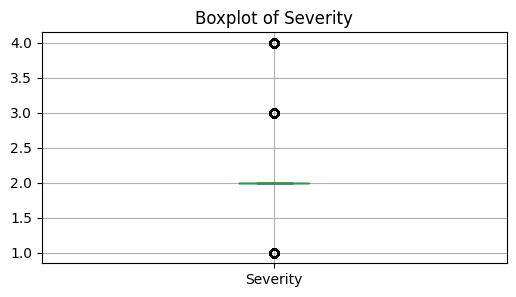

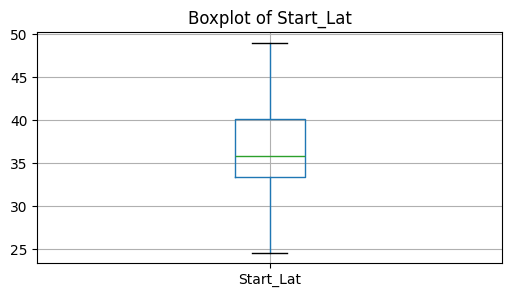

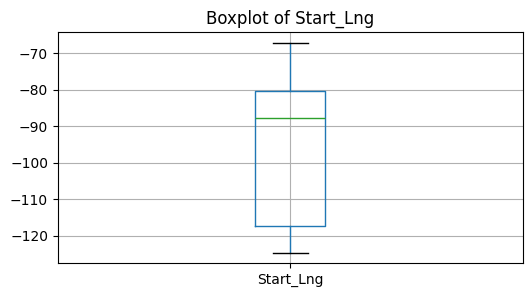

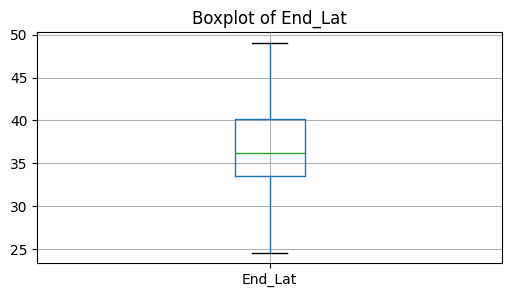

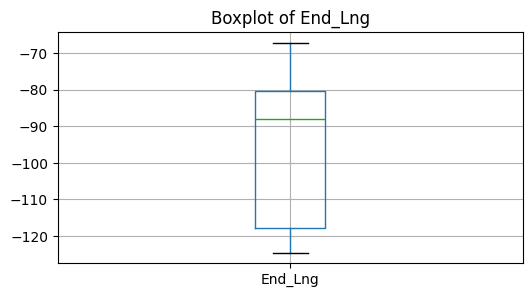

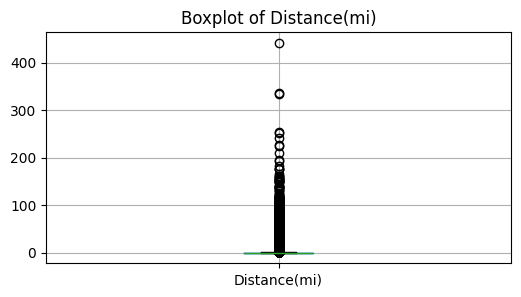

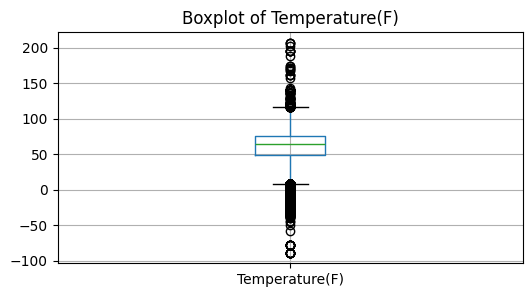

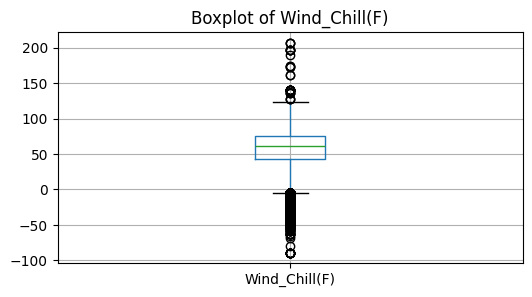

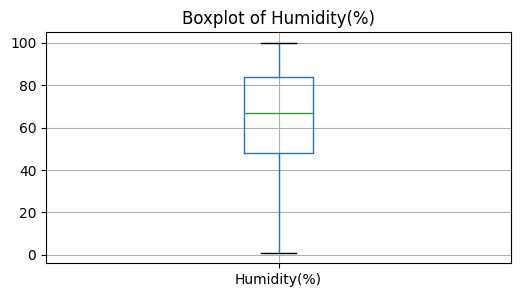

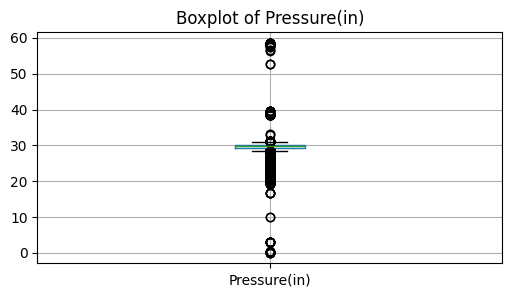

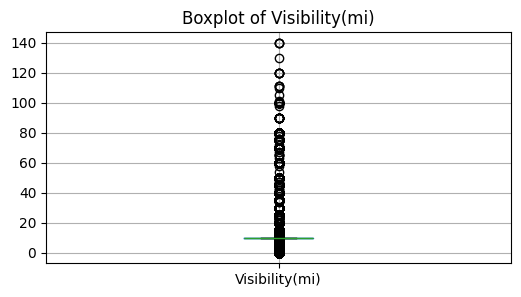

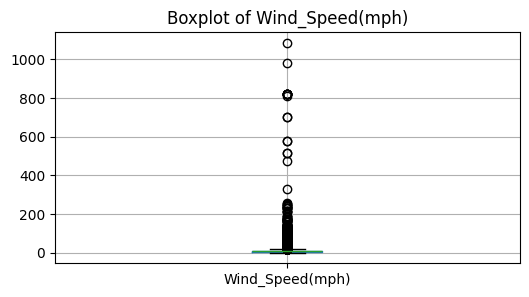

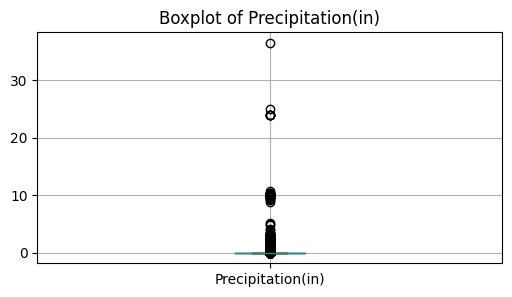

In [ ]:
# check outliers – create individual boxplot for each column
for column in df.select_dtypes(include="number").columns:
	plt.figure(figsize=(6,3))
	df[[column]].boxplot()
	plt.title(f"Boxplot of {column}")
	plt.show()

**distribution visualization**: This section is kind of practice to see the **scatter** and **violin** plots and better understand of distribution.

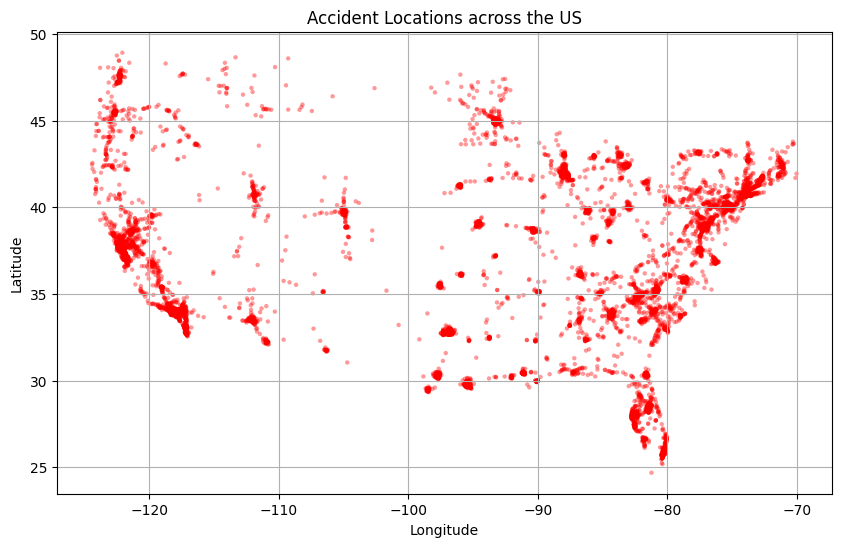

In [46]:
# scatter plot
sample_df = df.sample(n=10000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample_df['Start_Lng'], sample_df['Start_Lat'], c='red',
            alpha=0.4, s=10, edgecolors='none')
plt.title("Accident Locations across the US")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

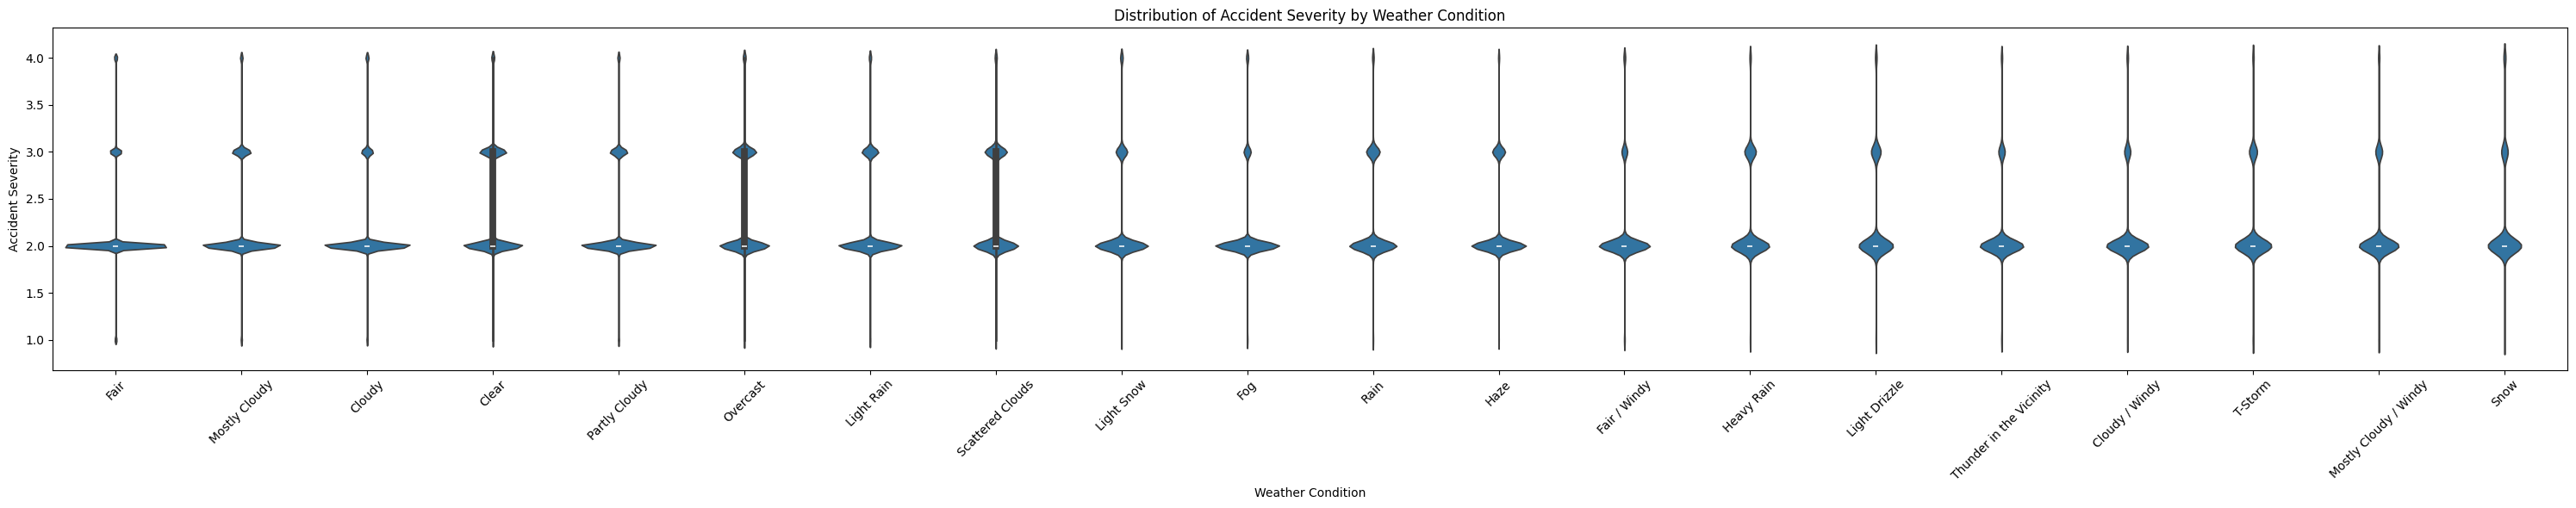

In [ ]:
# violin plot
top_conditions = df['Weather_Condition'].value_counts().nlargest(20).index
filtered_df = df[df['Weather_Condition'].isin(top_conditions)]
plt.figure(figsize=(30, 6))
sns.violinplot(data=filtered_df, x='Weather_Condition', y='Severity', order=top_conditions)
plt.xticks(rotation=45)
plt.title("Distribution of Accident Severity by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Severity")
plt.tight_layout()
plt.show()

#   <b><font color="navy" size="6">Data Preprocessing
</font></b>

In this step, I clean and prepare data to get it ready for analyzing.


1. **Remove columns with many missing values**  
The columns `End_Lat` and `End_Lng` have too many missing values and aren't important for my analysis so I delete them.

2. **Convert date columns**  
I convert `Start_Time` and `End_Time` to datetime format. They sometimes include fractional of seconds so I use this format: `'%Y-%m-%d %H:%M:%S.%f'`.
If any dates can't convert (become a `NaT`), I remove that rows because time info in so important for my analysis.
3. **Create time based features**  
From datetime columns I create new features: `Hour`, `Weekday`, `Month`, and `Year`. These features help see pattern over time, like when accidents mostly happen.

4. **Impute missing weather data**  
Weather is one of the important risk factors for accidents so I should make sure weather data is complete.
- for numerical columns (e.g. `Temperature(F)`, `Humidity(%)`, `Pressure(in)`, `Visibility(mi)`, `Wind_Speed(mph)`), I fill in missing values with the **median** value.  
- for `Weather_Condition` column, I fill in missing values with the **mode** (most common value).

After doing all the steps, the data become clean and decrease problems during analysis.


In [47]:
# exploring missing data
df[df['Weather_Condition'].isna()]

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
439,A-440,Source2,2,2016-03-01 17:23:06,2016-03-01 18:23:06,40.20,-83.03,NaN,NaN,0.00,Accident on Pullman Dr at Lewis Center Rd.,Lewis Center Rd,Lewis Center,Delaware,OH,43035-9047,US,US/Eastern,KDLZ,2016-03-01 17:17:00,48.20,NaN,93.00,29.51,10.00,SSW,9.20,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
601,A-602,Source2,3,2016-03-11 07:28:40,2016-03-11 07:58:40,41.32,-82.62,NaN,NaN,0.01,Accident on I-80 Eastbound near Exit 118 US-25...,US Highway 250 N,Milan,Erie,OH,44846,US,US/Eastern,KPCW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1478,A-1479,Source2,3,2016-06-27 20:42:18,2016-06-27 22:12:18,38.64,-121.52,NaN,NaN,0.00,Accident on I-5 Northbound at Exit 522 I-80.,I-5 N,Sacramento,Sacramento,CA,95834,US,US/Pacific,KMCC,2016-06-27 20:35:00,95.00,NaN,20.00,29.87,10.00,SW,6.90,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
1685,A-1686,Source2,2,2016-06-29 14:44:14,2016-06-29 15:29:14,37.13,-121.63,NaN,NaN,0.00,Accident on US-101 at Exit 366 / Dunne Ave.,S Valley Fwy N,Morgan Hill,Santa Clara,CA,95037,US,US/Pacific,KE16,2016-06-29 14:55:00,91.40,NaN,28.00,29.94,10.00,NNW,15.00,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1957,A-1958,Source2,2,2016-07-03 03:54:45,2016-07-03 04:40:40,37.90,-122.51,NaN,NaN,0.00,Accident on US-101 Northbound at Exits 447 447...,Tiburon Blvd,Mill Valley,Marin,CA,94941-2440,US,US/Pacific,KDVO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,False,False,False,False,False,False,True,False,Night,Night,Night,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728156,A-7777524,Source1,2,2019-08-23 12:23:00,2019-08-23 13:45:00,40.71,-111.55,40.70,-111.55,0.13,At UT-248/Kearns Blvd - Accident.,Highway 224,Park City,Summit,UT,84098-5954,US,US/Mountain,K36U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
7728162,A-7777530,Source1,2,2019-08-23 13:23:00,2019-08-23 14:30:00,40.79,-111.45,40.79,-111.45,0.41,At Tollgate Canyon Rd/Exit 150 - Accident.,I-80 W,Coalville,Summit,UT,84017,US,US/Mountain,K36U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
7728250,A-7777618,Source1,2,2019-08-23 17:19:55,2019-08-24 03:11:30,44.12,-121.32,44.12,-121.32,0.05,At Old Bend-Redmond Hwy - Accident.,Highway 20,Bend,Deschutes,OR,97703-8588,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
7728305,A-7777673,Source1,2,2019-08-23 23:48:20,2019-08-24 03:48:20,44.16,-121.26,44.13,-121.28,2.03,At NE Cooley Rd - Accident.,N Highway 97,Bend,Deschutes,OR,97703,US,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night


In [63]:
df = df.copy()

# remove columns
cols_to_drop = ['End_Lat', 'End_Lng']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# convert date columns
df.loc[:, 'Start_Time'] = pd.to_datetime(df['Start_Time'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
df.loc[:, 'End_Time']   = pd.to_datetime(df['End_Time'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
df.loc[:, 'Hour'] = df['Start_Time'].dt.hour

# remove rows with dates which can't be converted
df = df.dropna(subset=['Start_Time', 'End_Time'])

# create time based features
df.loc[:, 'Hour'] = df['Start_Time'].dt.hour
df.loc[:, 'Weekday'] = df['Start_Time'].dt.day_name()
df.loc[:, 'Month'] = df['Start_Time'].dt.month
df.loc[:, 'Year'] = df['Start_Time'].dt.year

# impute missing weather data
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in num_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())

# impute missing values in weather condition with mode
cat_cols = ['Weather_Condition']
for col in cat_cols:
    df.loc[:, col] = df[col].fillna(df[col].mode()[0])

# show data type and count missing values
print("Updated Data Types:")
print(df.dtypes)
print("Missing values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Updated Data Types:
ID                               object
Source                           object
Severity                          int64
Start_Time               datetime64[ns]
End_Time                 datetime64[ns]
Start_Lat                       float64
Start_Lng                       float64
Distance(mi)                    float64
Description                      object
Street                           object
City                             object
County                           object
State                            object
Zipcode                          object
Country                          object
Timezone                         object
Airport_Code                     object
Weather_Timestamp                object
Temperature(F)                  float64
Wind_Chill(F)                   float64
Humidity(%)                     float64
Pressure(in)                    float64
Visibility(mi)                  float64
Wind_Direction                   object
Wind_Speed(mph)     

#   <b><font color="navy" size="6">Explanatory Data Analysis
</font></b>


###**1- Which states and cities have most accidents?**
**Why it's important:**
It's so important for insurance companies to know which state/city has most accidents. places with many accidents have more risks. This may cause how many customers they will get, what policies they should have and where to have more offices. Big and crowded cities or which ones have heavy traffic should have extra safety to reduce risks.

**What I will do:**
- count how many accidents happen in each state
- count how many accidents happen in each city
- display top 10 states and top 10 cities with most accidents

In [52]:
# accidents per state and city
state_counts = df['State'].value_counts()
city_counts = df['City'].value_counts()

# top 10 results
print("Top 10 States by Number of Accidents:")
print(state_counts.head(10))
print("Top 10 Cities by Number of Accidents:")
print(city_counts.head(10))

Top 10 States by Number of Accidents:
State
CA    174297
FL    114567
VA     41656
TX     38030
NY     37609
PA     35412
SC     31525
NC     28328
MN     20196
OR     16852
Name: count, dtype: int64
Top 10 Cities by Number of Accidents:
City
Miami          30375
Orlando        16115
Los Angeles    14039
Dallas          9958
Houston         9649
Charlotte       8120
Raleigh         6590
Sacramento      6386
San Diego       6141
Nashville       5823
Name: count, dtype: int64


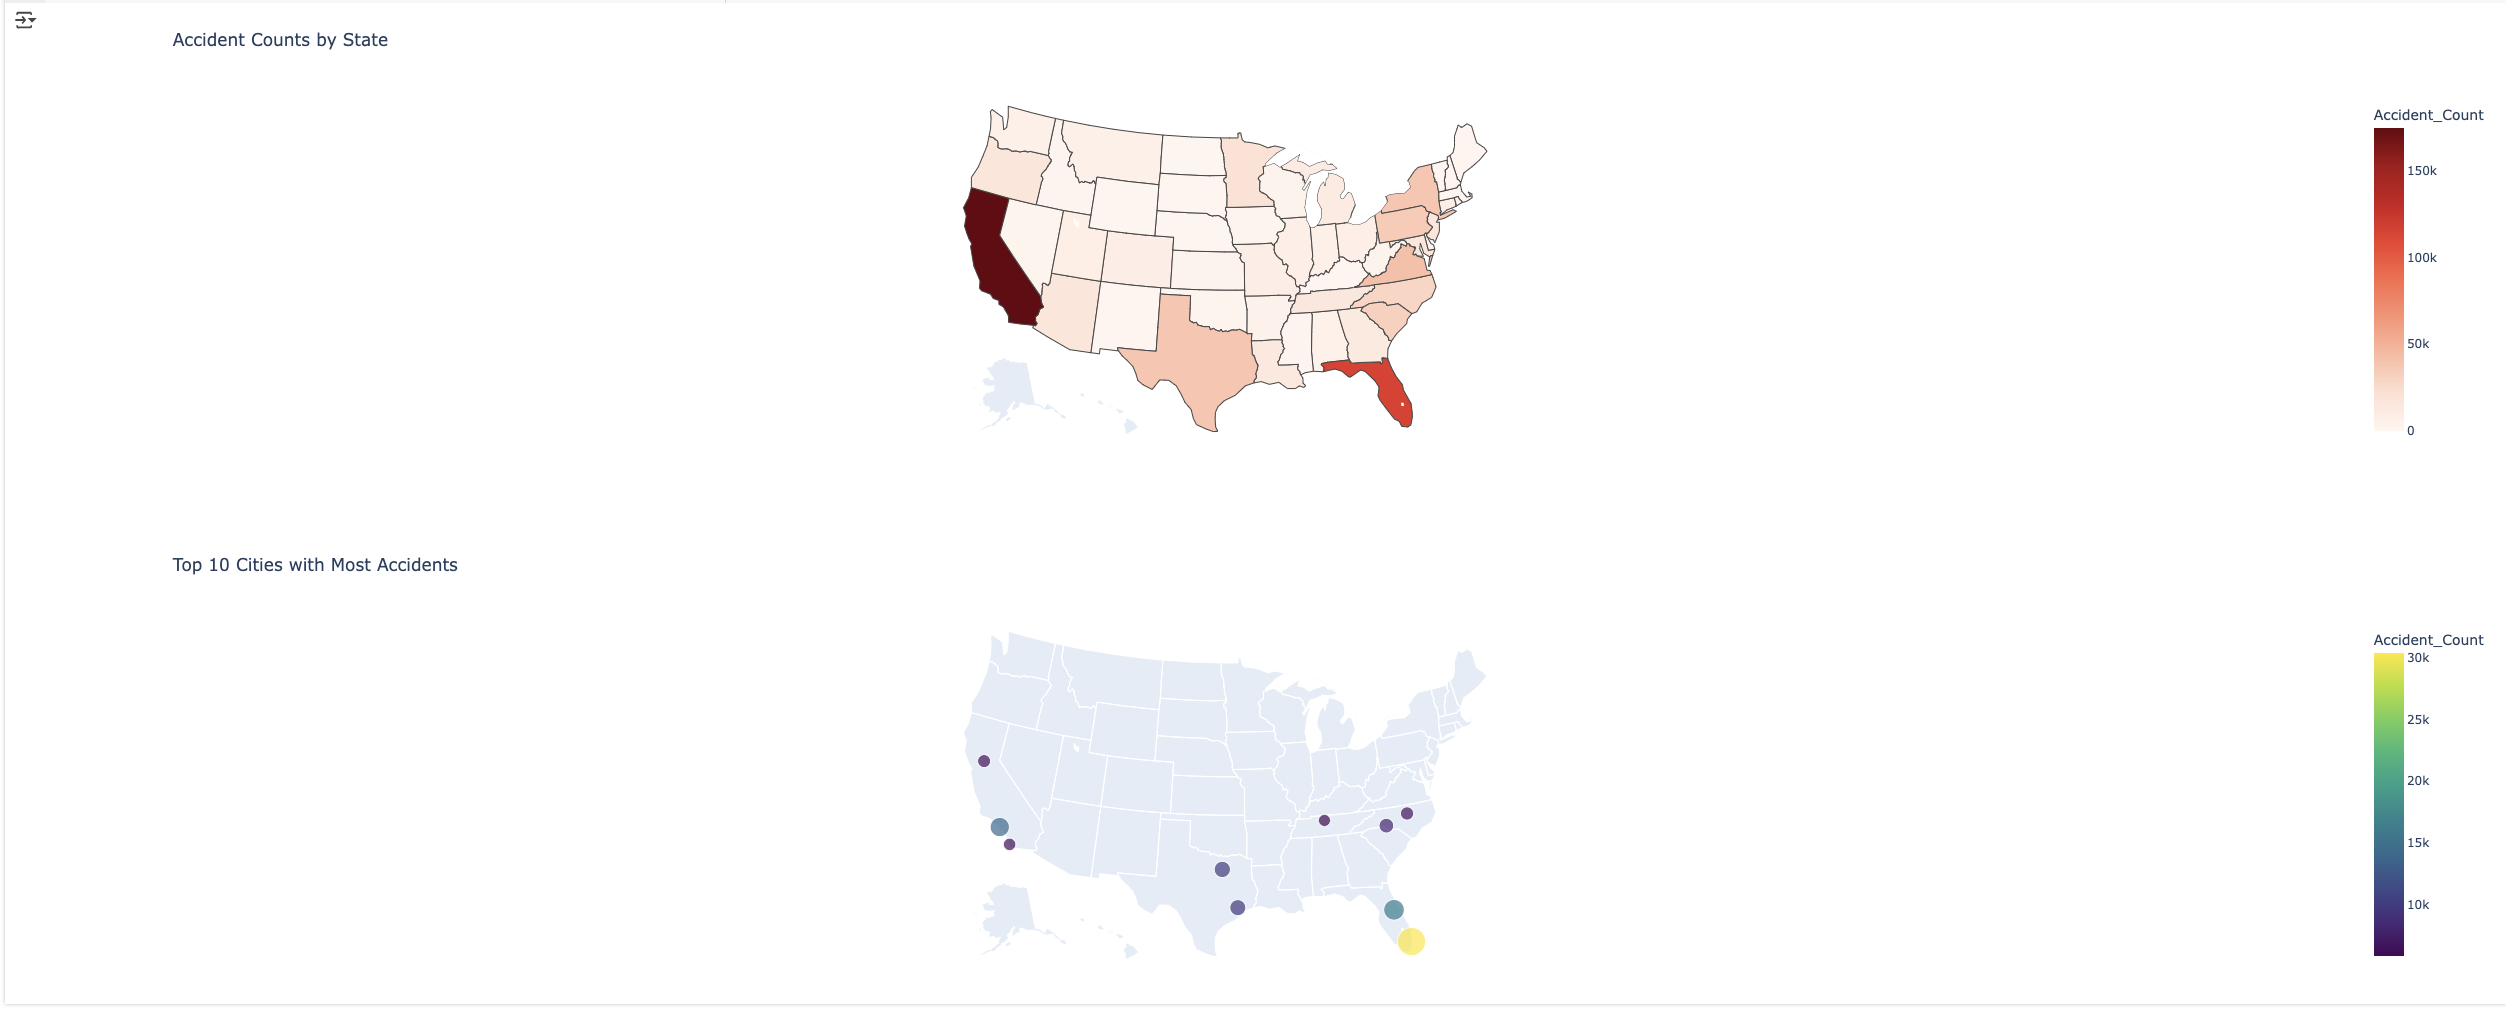I have below code that shows results on map but unfortunately when I converted it to html, they didn't show up. so I don't run the code here and attach a screenshot of the maps.

In [ ]:
# count accidents per state
accidents_by_state = df.groupby("State").size().reset_index(name="Accident_Count")

fig = px.choropleth(
    accidents_by_state,
    locations="State",
    locationmode="USA-states",
    color="Accident_Count",
    color_continuous_scale="Reds",
    scope="usa",
    title="Accident Counts by State"
)
fig.show()


# count accidents per city
top10_cities_coords = df[df['City'].isin(city_counts.head(10).index)]
top10_cities_coords = top10_cities_coords.groupby('City', as_index=False).first()
top10_cities_coords['Accident_Count'] = top10_cities_coords['City'].map(city_counts)

fig_city = px.scatter_geo(
    top10_cities_coords,
    lat='Start_Lat',
    lon='Start_Lng',
    size='Accident_Count',
    color='Accident_Count',
    hover_name='City',
    title="Top 10 Cities with Most Accidents",
    projection="albers usa",
    color_continuous_scale="Viridis"
)

fig_city.show()

According to results California (CA) has highest number of accidents, 174297.
next one is Florida (FL) with 114567. another ones are:
- Virginia (VA)
- Texas (TX)
- New York (NY)
- Pennsylvania (PA)
- South Carolina (SC)
- North Carolina (NC)
- Minnesota (MN)
- Oregon (OR)

These states are usually big with big population and so many roads.

for citites, Miami has most accidents. another ones are:
- Orlando
- Los Angeles
- Dallas
- Houston
- Charlotte
- Raleigh
- Sacramento
- San Diego
- Nashville

So big cities have more accidents, because they have more traffic and crowded roads.

**What it means for insurance companies:**

- **Risk management:** States/citites with more accidents are more risky. With this data company can figure out where problems happen.
- **Setting fair prices:** States/citites with more accidents need higher costs.
-**Claims management:** States/citites with more accidents need more staffs and faster services to manage claims.
- **Safety programs:** Company can work with local government for improve roads safety or plan campaigns to teach people.



### **2- How does weather effect how bad accidents are? (using weather conditions)**
**Why it's important:** Weather can change drive safety. Instead of put weather in big group, I look at 10 weather types to see how each one effect accidents.

**What I will do:**
- found 10 common weather types
- calculate average accident severity of each condition
- plot chart to compare

Top 10 Weather Conditions:
Fair
Cloudy
Mostly Cloudy
Partly Cloudy
Light Rain
Light Snow
Fog
Rain
Haze
Fair / Windy
Average Accident Severity for Top Weather Conditions:
Weather_Condition
Fog             2.07
Cloudy          2.07
Fair / Windy    2.07
Light Snow      2.06
Fair            2.05
Light Rain      2.05
Partly Cloudy   2.05
Rain            2.05
Mostly Cloudy   2.04
Haze            2.02
Name: Severity, dtype: float64


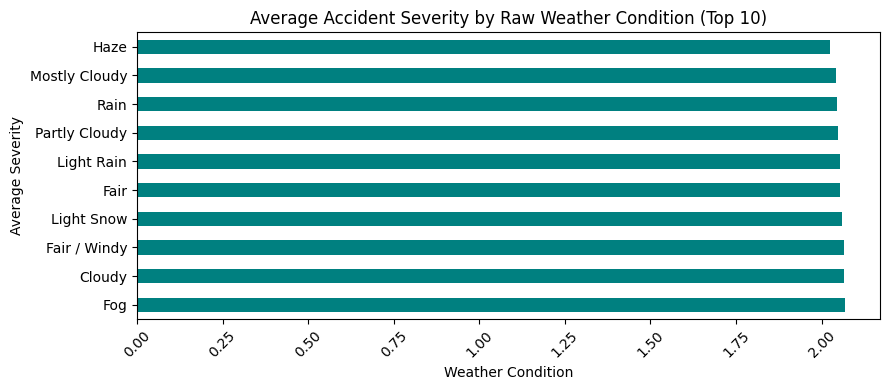

In [54]:
# found 10 common weather types
top_weather = df['Weather_Condition'].value_counts().head(10)
weather_conditions = top_weather.index.tolist()

print("Top 10 Weather Conditions:")
for condition in weather_conditions:
    print(condition)

# calculate the average accident severity
raw_weather_avg_severity = df_top_weather.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False)
print("Average Accident Severity for Top Weather Conditions:")
print(raw_weather_avg_severity)

# plot chart
plt.figure(figsize=(9, 4))
raw_weather_avg_severity.plot(kind='barh', color='teal')
plt.title('Average Accident Severity by Raw Weather Condition (Top 10)')
plt.xlabel('Weather Condition')
plt.ylabel('Average Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I look at the average accident severity for the top 10 weather conditions. the results are:
- **Fog:** 2.067  
- **Cloudy:** 2.065  
- **Fair / Windy:** 2.065  
- **Light Snow:** 2.059  
- **Fair:** 2.055  
- **Light Rain:** 2.053  
- **Partly Cloudy:** 2.047  
- **Rain:** 2.045  
- **Mostly Cloudy:** 2.041  
- **Haze:** 2.024  

**What I see:**
- **Very narrow range**:

  The average scores are so close to each other. From 2.024 to 2.067 on a scale of 1 to 4 (1= least severe, 4 = most severe). This means weather condition has effect on accident severity but it's not a lot when we looking at the average.
- **Slight pattern:**
  - Accidents in **fog** and **cloudy** weather have the highest average severity (around 2.066).
  - **Haze** and **mostly cloudy** weather show slightly lower average severity (around 2.024–2.041).
  - These hint that bad visibility conditions, like fog, or conditions that affect driver behaivor, like fair/windy, can increase accident severity.

**What it means:**

However the differences are small but they still can matter because there are large volume of accidents. Even small change, like 0.004 to 0.05, can cause higher claim costs. Also severity score has only few levels (1 to 4), so it can not show the exact impact of weather condition. Weather has impact on `how often` accidents happen more than `how serious` they are.


**What it means for insurance companies:**

- **Risk modeling:** Even small changes in accidents based on weather can improve risk models. for example, if fog can cause a serioud accident so insurance in foggy states/citiies can have a bit more costs.

- **Preventative measures:** However weather conditons have small effect on accident severity but companies can work with local government for more safety. for example, adding more lights in foggy areas can decrease accidents.




###**3- What time of the day have most accidents?**
**Why it's important:**

If insurance company knows what time of the day has most accidents can make smart decisions. such as:
- **Usage based insurance (UBI):** This is a kind of car insurance where you pay according to `how` and `when` you drive. for example when you drive in safe times of the day like early morning, your insurance cost less.
Insurance use this to offer fair prices according your driving habits.
-**Better planning:** they can schedule to have more sttafs during busy hours.

**What I will do:**

- group accidents by each houre of the day
- count how many accidents happen in each hour
- plot a chart to see clearly what time of the day has most accidents



Accident Counts by Hour:
Hour
0     13926
1     11328
2     10833
3      9634
4     10775
5     18603
6     30658
7     40683
8     35933
9     28967
10    29081
11    32825
12    38097
13    44084
14    54149
15    62466
16    61792
17    59389
18    41421
19    28076
20    23343
21    21952
22    19040
23    16111
Name: ID, dtype: int64


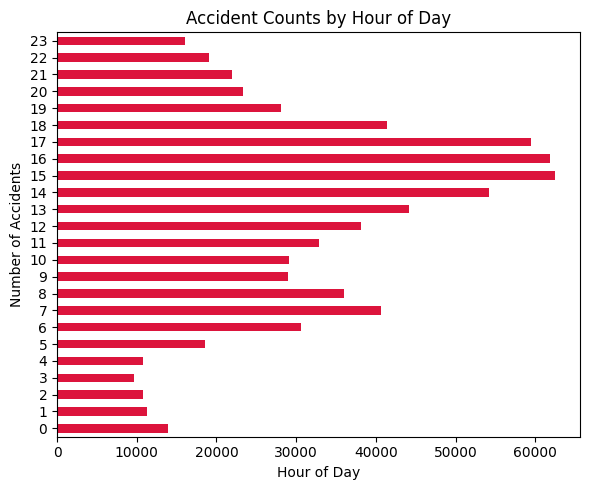

In [55]:
# group accidents by each houre of the day
hour_counts = df.groupby('Hour')['ID'].count()
print("Accident Counts by Hour:")
print(hour_counts)

# plotting accidents in each hour
plt.figure(figsize=(6,5))
hour_counts.plot(kind='barh', color='crimson')
plt.title('Accident Counts by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

According to the chart, number of accidents change during the day.
- **Late night to early morning (0-4am):**
  
  Low accidents happen during this period (9,600–11,400) because there are fewer cars in the roads.

- **Morning rush (5-8am):**

  Accidents start increasing at 5am with a sharp increase at 6am (30,658 accidents). The peak is at 7am (40,683 accidents), right during the morning rush hours.

- **Afternoon rush (14-17pm):**  

  Accident numbers get higher in the afternoon. at 3pm there are the most accidents (about 62,466). This is the busiest and riskiest period of the day.

- **Evening (18-23pm):**  
  After 17pm accidents decrease slowly because traffic get lighter.

**What it means for insurance companies:**
- **Usage based insurance (UBI):** Insurance companies can use this data to charge their customers. Drivers who drive during busy hours must pay more.
- **Staff and support:** They can plan better if they have these data. for example they should have more staffs in afternoon peak to handle better and faster.


###**4- Are there seasonal patterns in accidents?**
**Why it's important:**

Accidents may happen more during sertain times of the year, for example in winter because of snow or during holidays when more people are on roads. If insurance companies spot some patterns, it can help them:
- **Prepare for busy times:** They can set enough money and sttaf for handle the claims.
- **Adjust prices:** They can change prices depending on season or if sometimes of the year have more accidents.


**What I will do:**

- group accidents data by month
- plot a chart to see clearly what times of the year have more accidents

Accident Counts by Month:
Month
1     99264
2     73378
3     53233
4     61090
5     52562
6     46623
7     49072
8     52460
9     57566
10    44805
11    64553
12    88560
Name: ID, dtype: int64


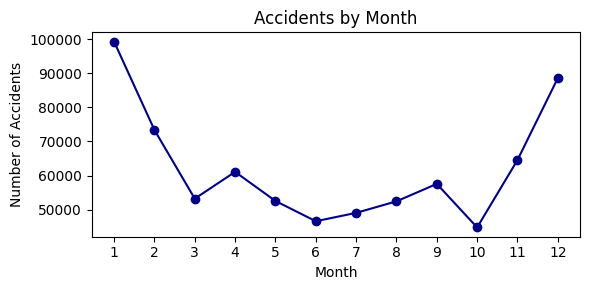

In [56]:
# group accidents data by month
month_counts = df.groupby('Month')['ID'].count()
print("Accident Counts by Month:")
print(month_counts)

# plotting the accident counts by month
plt.figure(figsize=(6,3))
month_counts.plot(marker='o', linestyle='-', color='darkblue')
plt.title('Accidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Chart shows that:
- **Winter months:** January and december have most accident because of new year holiday (travels) and weather condition (snow and ice).
- **Early spring and late fall:** In febaury and november accidents drop about 73,378 or even lower around 64,553. So these two months are safer than winter peak.
- **Summer months:** June and july are vacation months but they have lower accidents in compare with winter.
- **Other months:** March, april, may, august and september are in the middle, not a high as winter and not as low as summer.

**What it means for insurance companies:**
- **Staff and support:** They exoect more accident during winter months so they plan to have more staff and services for better and faster support.
- **Adjust prices:** They can change the costs based of the seasons. like drivers in states/cities with hard and bad winter should pay more.

###**5- How does accident severity relate to road conditions?**
**Why it's important:**

Roads condition may have impact on accident severity. If there is traffic light in at intersection can reduce accidents or crashes. So knowing the roads condition help insurance companies in:

- have rules for risk measuring
- change prices according to location
- work with local government for having more safe roads

**What I will do:**
- check accidents in roads with or without traffic lights
- calculate average severity
- show results for review

In [57]:
# check accidents in roads with or without traffic lights
sev_with_signal = df[df['Traffic_Signal'] == True]['Severity'].value_counts(normalize=True) * 100
sev_without_signal = df[df['Traffic_Signal'] == False]['Severity'].value_counts(normalize=True) * 100

print("Severity Distribution (With Traffic Signal) [%]:")
print(sev_with_signal.sort_index())

print("Severity Distribution (Without Traffic Signal) [%]:")
print(sev_without_signal.sort_index())

# calculate average severity
avg_sev_with_signal = df[df['Traffic_Signal'] == True]['Severity'].mean()
avg_sev_without = df[df['Traffic_Signal'] == False]['Severity'].mean()

print("Average Severity With Traffic Signal:", avg_sev_with_signal)
print("Average Severity Without Traffic Signal:", avg_sev_without)

Severity Distribution (With Traffic Signal) [%]:
Severity
1    0.00
2   96.87
3    0.00
4    3.13
Name: proportion, dtype: float64
Severity Distribution (Without Traffic Signal) [%]:
Severity
1    0.00
2   97.34
3    0.01
4    2.65
Name: proportion, dtype: float64
Average Severity With Traffic Signal: 2.0625708578524
Average Severity Without Traffic Signal: 2.053175042939396


The analysis of accidents severity in roads with or without traffic lights give these:

**Severity levels**

- **With traffic lights:**
  - Most accidents like 96.87% weren't that much serious (level 2), few of them were so serious (level 4), almost none were very mild (level 1) or serious (level 3).

- **Without traffic lights:**
  - most accidents like 97.34% weren't that much serious (level 2), few of them were so serious (level 4) and a slightly higher number were severity 3 but they are still so low.

**Average severity**
- average severity with traffic lights is 2.06.
- average severity without traffic lights is 2.05.

This means there is almost no difference (0.0094) between them.

**What it means for insurance companies:**

- **Risk modeling:** Data show small differences in severity but small changes are still important. for better decision check others things like speed limits, Quality of asphalt, road design, crosswalks and junctions can help.

- **Further snalysis:** Data show small differences in severity so study on other part can help. For example we can study deeper on accidents in level 4.


###**6- What kind of accidents happen most and cost most?**
**Why it's important:**
All kind of accidents don't have same effect. I break them down:
- **Minor accidents:** like severity level 2, happen more but costs less.
- **Severe accidents:** like severity level 4, don't happen often but cost very expensive.

**What I will do:**
- Count how many accidents fall into each severity level
- Calculate percentage for each level
- plot a chart to see clearly what kind of accidents happen most

Accident Counts by Severity:
Severity
1         2
2    723103
3        80
4     19981
Name: count, dtype: int64
Accident Percentage by Severity:
Severity
1   0.00
2   0.97
3   0.00
4   0.03
Name: proportion, dtype: float64


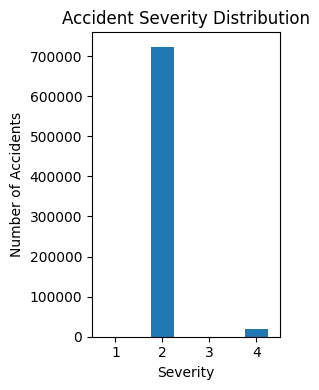

In [58]:
# count of accidents by severity
severity_counts = df['Severity'].value_counts().sort_index()
severity_percent = df['Severity'].value_counts(normalize=True).sort_index()

print("Accident Counts by Severity:")
print(severity_counts)
print("Accident Percentage by Severity:")
print(severity_percent)

# plot the severity distribution
plt.figure(figsize=(3,4))
severity_counts.plot(kind='bar')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

According to the results most accident aren't so serious and a few of them are very bad:

- **Most common (severity 2):**
  - about 97.3%
  - these are minor ones and don't cost high.
  - but they are the main ones so totally they cost high.

- **Very serious (severity 4):**
  - about 2.69%
  - these are rare and cost high
  - so these are very important to increase or decrease risks.

- **Very rare severity (1, 3):**
  - almost 0%
  - so this show most accidents are minor (lvl 2) or serious (lvl 4).

**What it means for insurance companies:**

- **Risk and money modeling:**
  - most claims are small but happen mostly, so it's easy for planning.
  - serious accidents don't happen a lot but cost very high, so they need to save funds.

- **Adjust prices:**
  - they should cover all type of severity but they should have extra funds to handle few big and very serious ones.


#   <b><font color="navy" size="6">Final Discussion and Conclusion
</font></b>


**Findings:**
- **Geography:**  
A few states, especially California and Florida, have most accidents. Cities like Miami, Orlando, Los Angeles, Dallas and Houston also have a lots of crashes. So this locations need extra attention to managing risk and improving safety.
- **Weather impact:**  
Some weather types, like fog, cloudy or windy, are linked to more serious accidents. However differences is small but bad weather increase risk.

- **Temporal patterns:**  
  - accidents happen more during morning and evening rush hours, especially during the early to mid afternoon.
  - accidents happen more in winter months (december and january), because of bad weather and also holiday travels.
  - during summer a few accidents happen.

- **Accident severity:**  
  - most accidents (97%) are severity 2 that they’re minor.
  - severe accidents (severity 4) are rare ( 2.7%) but they're very expensive.
  - mix of many small accidents and a few big accidents are  very important for planning and also pricing.

**Recommendation for insurance companies**

1. **Regional prices:**  
  - they must have especial prices and rules for eash state/city.
  - they must have discounts in high risk states/cities to encourage drivers to drive safe.

2. **Weather based risk models:**  
   - they must add weather data in their pricing models.
   - they must work with government to make roads mor safe.

3. **Usage based insurance:**  
   - they must use telematic for track how and when people drive.
   - high price for drivers who drive during risky hours.
   - low price for drivers who drive during off peak hours.
  
4. **Seasonal preparation:**  
   - they must ready for bif claims during winte.
   - they must have more staffs and services duting winter.

5. **Prepare for high cost serious accidents:**  
   - they must be prepare for severity 4 accidents. they are rare but cost so high.
   - they must make sure deductibles and reinsurance can cover big claims.



In [59]:
!jupyter nbconvert --to html "/content/M504_SamiraTafteh_GH1027985.ipynb"

[NbConvertApp] Converting notebook /content/M504_SamiraTafteh_GH1027985.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 19 image(s).
[NbConvertApp] Writing 1698992 bytes to /content/M504_SamiraTafteh_GH1027985.html


In [61]:
from google.colab import files
files.download("/content/M504_SamiraTafteh_GH1027985.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>